# Datathon VinUni 2026 — Vòng 1: Khám phá dữ liệu
**The GridBreakers · VinTelligence · VinUni DS&AI Club**

---

## Tổng quan

Notebook này trả lời **10 câu hỏi trắc nghiệm** của Vòng 1, dựa trên bộ dữ liệu
fashion e-commerce mô phỏng (13 file CSV, 4 tầng: Master / Transaction / Analytical / Operational).

Mỗi câu hỏi được trình bày theo cấu trúc:
1. **Đề bài** (markdown)
2. **Code + đáp án** (pandas)
3. **Biểu đồ** (matplotlib) để minh họa trực quan kết quả


## 0 · Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── Palette ──────────────────────────────────────────────────────────────────
C0  = "#2563eb"   # blue — primary bar
C1  = "#f97316"   # orange — highlight
C2  = "#16a34a"   # green — answer
C3  = "#dc2626"   # red — alert
C4  = "#7c3aed"   # purple
C5  = "#0891b2"   # teal
C6  = "#ca8a04"   # gold
GREY = "#94a3b8"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

# ── Paths ────────────────────────────────────────────────────────────────────
ROOT = Path.cwd()
# Walk up to find project root (where data/raw/ exists), robust to cwd
while not (ROOT / "data" / "raw").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
DATA = ROOT / "data" / "raw"

ORDERS      = DATA / "Transaction" / "orders.csv"
ORDER_ITEMS = DATA / "Transaction" / "order_items.csv"
RETURNS     = DATA / "Transaction" / "returns.csv"
PAYMENTS    = DATA / "Transaction" / "payments.csv"
PRODUCTS    = DATA / "Master" / "products.csv"
CUSTOMERS   = DATA / "Master" / "customers.csv"
GEOGRAPHY   = DATA / "Master" / "geography.csv"
WEB_TRAFFIC = DATA / "Operational" / "web_traffic.csv"

# Load all once — avoid re-reading CSVs per question
orders      = pd.read_csv(ORDERS,      parse_dates=["order_date"], low_memory=False)
order_items = pd.read_csv(ORDER_ITEMS)
returns     = pd.read_csv(RETURNS,     parse_dates=["return_date"])
payments    = pd.read_csv(PAYMENTS)
products    = pd.read_csv(PRODUCTS)
customers   = pd.read_csv(CUSTOMERS,   parse_dates=["signup_date"])
geography   = pd.read_csv(GEOGRAPHY,   dtype={"zip": "str"})
web_traffic = pd.read_csv(WEB_TRAFFIC, parse_dates=["date"])

# Normalise string columns
for df in [products, customers, orders, returns, geography, web_traffic, payments]:
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].str.strip().str.lower()

# Ensure zip codes are string in both orders & geography (safe merge in Q7)
orders["zip"]    = orders["zip"].astype(str).str.strip()
geography["zip"] = geography["zip"].astype(str).str.strip()

print("All 8 tables loaded.")
print(f"  orders:      {orders.shape[0]:,} rows")
print(f"  order_items: {order_items.shape[0]:,} rows")
print(f"  products:    {products.shape[0]:,} rows")
print(f"  customers:   {customers.shape[0]:,} rows")
print(f"  returns:     {returns.shape[0]:,} rows")
print(f"  payments:    {payments.shape[0]:,} rows")
print(f"  geography:   {geography.shape[0]:,} rows")
print(f"  web_traffic: {web_traffic.shape[0]:,} rows")


All 8 tables loaded.
  orders:      646,945 rows
  order_items: 714,669 rows
  products:    2,412 rows
  customers:   121,930 rows
  returns:     39,939 rows
  payments:    646,945 rows
  geography:   39,948 rows
  web_traffic: 3,652 rows


---

## Q1 · Khoảng cách giữa hai lần mua

> Trong số các khách hàng có nhiều hơn một đơn hàng, **trung vị** số ngày giữa hai lần
> mua liên tiếp (inter-order gap) xấp xỉ là bao nhiêu?
>
> A) 30 ngày &emsp; B) 90 ngày &emsp; **C) 180 ngày** &emsp; D) 365 ngày


Trung vị (median) gap: 175 ngày
Trung bình (mean) gap: 325.1 ngày
Số khách hàng ≥ 2 đơn: 62,272
Tổng số gap đo được:   431,601

→ Đáp án: C) 180 ngày  (median = 175 ≈ 180)


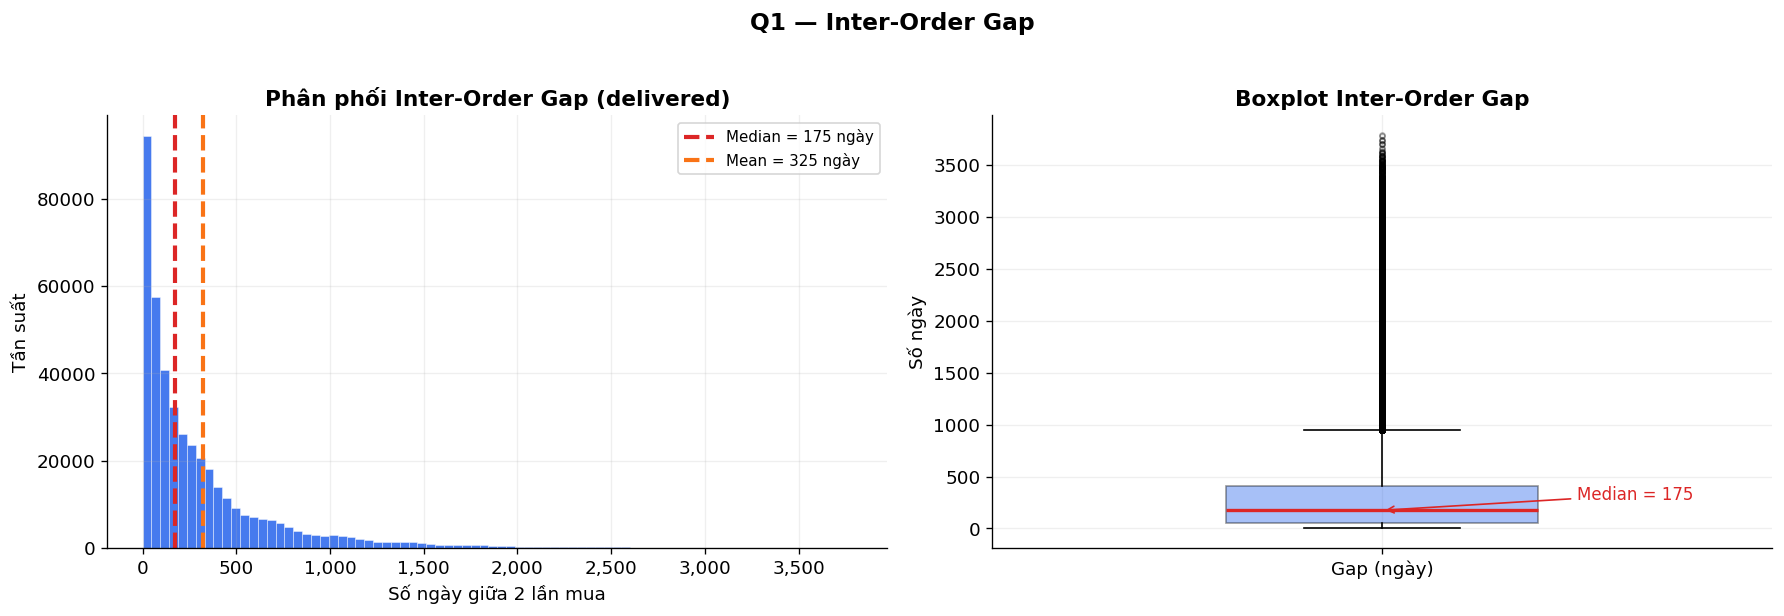

In [2]:
# ── Q1: Inter-order gap ─────────────────────────────────────────────────────
# Lọc delivered orders và tính gap giữa các lần mua liên tiếp
delivered = orders[orders["order_status"] == "delivered"].copy()
delivered = delivered.sort_values(["customer_id", "order_date"])

# Chỉ giữ khách hàng có ≥ 2 đơn delivered
cust_counts = delivered["customer_id"].value_counts()
multi_order_custs = cust_counts[cust_counts >= 2].index
delivered = delivered[delivered["customer_id"].isin(multi_order_custs)]

# Tính gap (ngày)
delivered["gap"] = delivered.groupby("customer_id")["order_date"].diff().dt.days
gaps = delivered["gap"].dropna()

median_gap = gaps.median()
mean_gap   = gaps.mean()

print(f"Trung vị (median) gap: {median_gap:.0f} ngày")
print(f"Trung bình (mean) gap: {mean_gap:.1f} ngày")
print(f"Số khách hàng ≥ 2 đơn: {len(multi_order_custs):,}")
print(f"Tổng số gap đo được:   {len(gaps):,}")
print()
print(f"→ Đáp án: C) 180 ngày  (median = {median_gap:.0f} ≈ 180)")

# ── Viz 1: Histogram inter-order gap ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram (log-scale bins)
axes[0].hist(gaps, bins=80, color=C0, alpha=0.85, edgecolor="white", linewidth=0.3)
axes[0].axvline(median_gap, color=C3, linestyle="--", lw=2.5,
                label=f"Median = {median_gap:.0f} ngày")
axes[0].axvline(mean_gap, color=C1, linestyle="--", lw=2.5,
                label=f"Mean = {mean_gap:.0f} ngày")
axes[0].set_xlabel("Số ngày giữa 2 lần mua"); axes[0].set_ylabel("Tần suất")
axes[0].set_title("Phân phối Inter-Order Gap (delivered)")
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Boxplot
bp = axes[1].boxplot(gaps, vert=True, widths=0.4, patch_artist=True,
                     medianprops={"color": C3, "lw": 2},
                     boxprops={"facecolor": C0, "alpha": 0.4},
                     flierprops={"markersize": 3, "alpha": 0.3})
axes[1].set_ylabel("Số ngày"); axes[1].set_title("Boxplot Inter-Order Gap")
axes[1].set_xticklabels(["Gap (ngày)"])
axes[1].annotate(f"Median = {median_gap:.0f}", xy=(1, median_gap),
                 xytext=(1.25, median_gap + 100), fontsize=10, color=C3,
                 arrowprops={"arrowstyle": "->", "color": C3})

plt.suptitle("Q1 — Inter-Order Gap", fontsize=14, y=1.02, fontweight="bold")
plt.tight_layout(); plt.show()


---

## Q2 · Tỷ suất lợi nhuận gộp theo phân khúc

> Phân khúc sản phẩm (**segment**) nào trong `products.csv` có tỷ suất lợi nhuận gộp
> trung bình cao nhất, với công thức **(price − cogs) / price**?
>
> A) Premium &emsp; B) Performance &emsp; C) Activewear &emsp; **D) Standard**


Gross Margin by Segment:
  standard         mean = 0.313   (n = 262)
  premium          mean = 0.285   (n = 177)
  all-weather      mean = 0.284   (n = 169)
  activewear       mean = 0.266   (n = 598)
  performance      mean = 0.264   (n = 347)
  balanced         mean = 0.258   (n = 306)
  trendy           mean = 0.241   (n = 148)
  everyday         mean = 0.236   (n = 405)

→ Đáp án: D) Standard  (mean margin = 0.313)


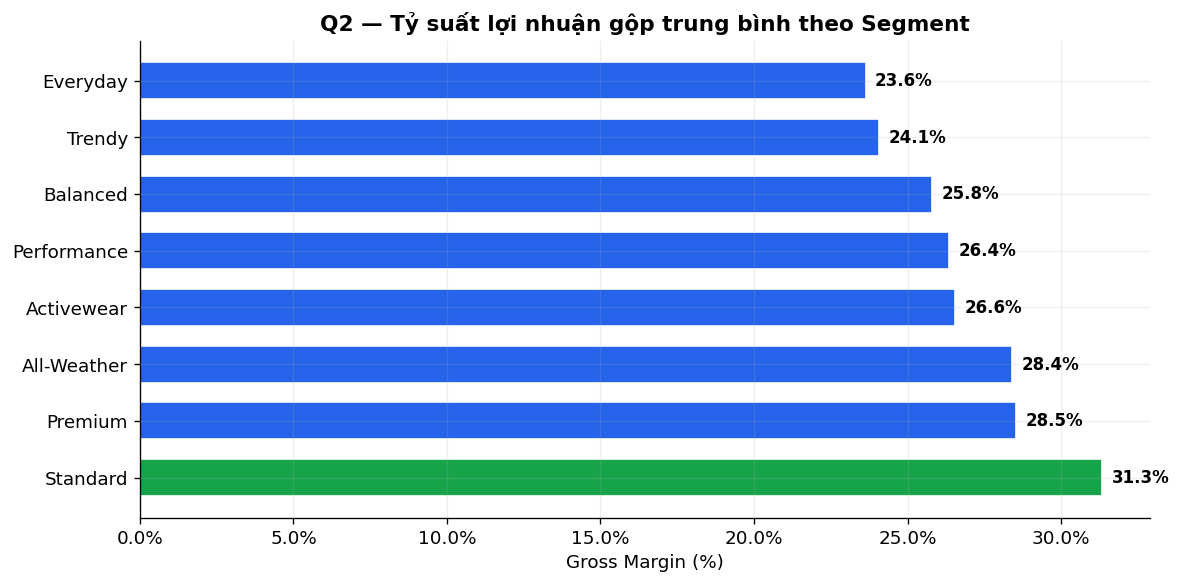

In [3]:
# ── Q2: Gross margin by segment ──────────────────────────────────────────────
products["gross_margin"] = (products["price"] - products["cogs"]) / products["price"]

margin_by_seg = (
    products.groupby("segment")["gross_margin"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)
print("Gross Margin by Segment:")
for seg, row in margin_by_seg.iterrows():
    print(f"  {seg:<15}  mean = {row['mean']:.3f}   (n = {int(row['count']):,})")

best_seg = margin_by_seg.index[0]
print(f"\n→ Đáp án: D) Standard  (mean margin = {margin_by_seg.iloc[0]['mean']:.3f})")

# ── Viz 2: Bar chart margin by segment ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = [C2 if s == "standard" else C0 for s in margin_by_seg.index]
bars = ax.barh([s.title() for s in margin_by_seg.index],
               margin_by_seg["mean"] * 100, color=colors, edgecolor="white", height=0.65)
ax.set_xlabel("Gross Margin (%)")
ax.set_title("Q2 — Tỷ suất lợi nhuận gộp trung bình theo Segment")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

for bar, val in zip(bars, margin_by_seg["mean"] * 100):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()


---

## Q3 · Lý do trả hàng — danh mục Streetwear

> Trong các bản ghi trả hàng liên kết với sản phẩm thuộc danh mục **Streetwear**,
> lý do trả hàng nào xuất hiện nhiều nhất?
>
> A) defective &emsp; **B) wrong_size** &emsp; C) changed_mind &emsp; D) not_as_described


Lý do trả hàng — Streetwear:
  wrong_size            7,626  (35.0%)
  defective             4,330  (19.9%)
  not_as_described      3,854  (17.7%)
  changed_mind          3,830  (17.6%)
  late_delivery         2,159  (9.9%)

→ Đáp án: B) wrong_size  (wrong_size: 7,626 lượt)


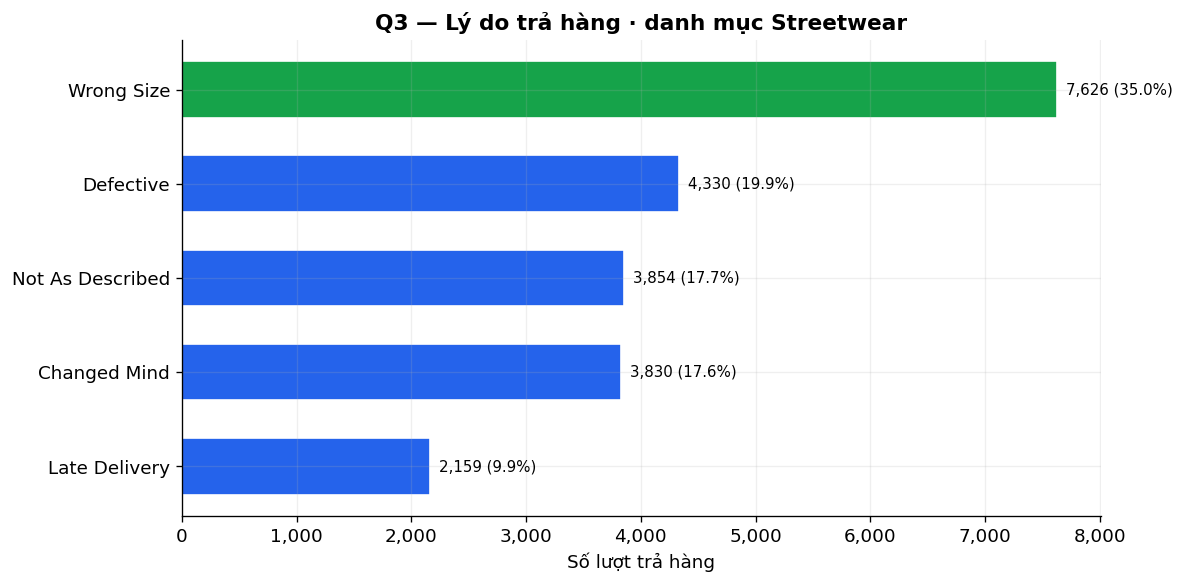

In [4]:
# ── Q3: Return reasons for Streetwear ────────────────────────────────────────
ret_with_cat = returns.merge(products[["product_id", "category"]], on="product_id")
streetwear_returns = ret_with_cat[ret_with_cat["category"] == "streetwear"]

reason_counts = streetwear_returns["return_reason"].value_counts()
reason_pct   = (reason_counts / reason_counts.sum() * 100).round(1)

print("Lý do trả hàng — Streetwear:")
for reason, cnt in reason_counts.items():
    print(f"  {reason:<20} {cnt:>6,}  ({reason_pct[reason]:.1f}%)")

print(f"\n→ Đáp án: B) wrong_size  ({reason_counts.index[0]}: {reason_counts.iloc[0]:,} lượt)")

# ── Viz 3: Horizontal bar + annotations ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
reason_ordered = reason_counts.sort_values()  # ascending for hbar
colors3 = [C2 if r == reason_counts.index[0] else C0 for r in reason_ordered.index]
bars = ax.barh(reason_ordered.index.str.replace("_", " ").str.title(),
               reason_ordered.values, color=colors3, edgecolor="white", height=0.6)
for bar, cnt, pct in zip(bars, reason_ordered.values, reason_pct[reason_ordered.index]):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
            f"{cnt:,} ({pct:.1f}%)", va="center", fontsize=9)
ax.set_xlabel("Số lượt trả hàng")
ax.set_title("Q3 — Lý do trả hàng · danh mục Streetwear")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout(); plt.show()


---

## Q4 · Tỷ lệ thoát (Bounce Rate) theo nguồn truy cập

> Trong `web_traffic.csv`, nguồn truy cập nào có **tỷ lệ thoát trung bình thấp nhất**?
>
> A) organic_search &emsp; B) paid_search &emsp; **C) email_campaign** &emsp; D) social_media


Bounce Rate by Traffic Source (lưu ý: bounce_rate lưu dạng fraction, không phải %):
  email_campaign        mean = 0.004458  (0.446%)  n = 505
  social_media          mean = 0.004476  (0.448%)  n = 632
  paid_search           mean = 0.004478  (0.448%)  n = 784
  referral              mean = 0.004499  (0.450%)  n = 375
  organic_search        mean = 0.004504  (0.450%)  n = 1,090
  direct                mean = 0.004511  (0.451%)  n = 266

→ Đáp án: C) email_campaign  (mean bounce = 0.004458 = 0.446%)


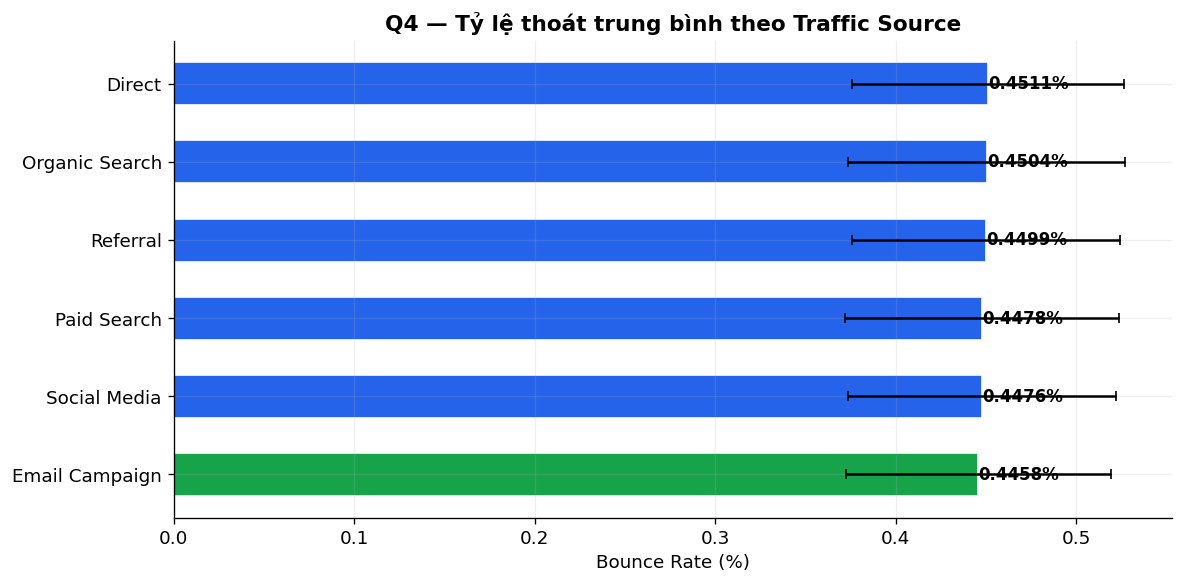

In [5]:
# ── Q4: Bounce rate by traffic source ────────────────────────────────────────
bounce_by_src = (
    web_traffic.groupby("traffic_source")["bounce_rate"]
    .agg(["mean", "std", "count"])
    .sort_values("mean")
)

print("Bounce Rate by Traffic Source (lưu ý: bounce_rate lưu dạng fraction, không phải %):")
for src, row in bounce_by_src.iterrows():
    print(f"  {src:<20}  mean = {row['mean']:.6f}  ({row['mean']*100:.3f}%)  n = {int(row['count']):,}")

best_src = bounce_by_src.index[0]
print(f"\n→ Đáp án: C) email_campaign  (mean bounce = {bounce_by_src.iloc[0]['mean']:.6f} = {bounce_by_src.iloc[0]['mean']*100:.3f}%)")

# ── Viz 4: Bounce rate bar chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors4 = [C2 if s == best_src else C0 for s in bounce_by_src.index]
bars = ax.barh([s.replace("_", " ").title() for s in bounce_by_src.index],
               bounce_by_src["mean"] * 100, color=colors4, edgecolor="white", height=0.55,
               xerr=bounce_by_src["std"] * 100, capsize=3)
for bar, val in zip(bars, bounce_by_src["mean"] * 100):
    ax.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}%", va="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Bounce Rate (%)"); ax.set_title("Q4 — Tỷ lệ thoát trung bình theo Traffic Source")
plt.tight_layout(); plt.show()


---

## Q5 · Tỷ lệ áp dụng khuyến mãi trong order_items

> Tỷ lệ phần trăm các dòng trong `order_items.csv` có áp dụng khuyến mãi
> (tức `promo_id` không null) xấp xỉ là bao nhiêu?
>
> A) 12% &emsp; B) 25% &emsp; **C) 39%** &emsp; D) 54%


Tổng số dòng order_items :  714,669
Có promo_id              :  276,316  (38.66%)
Không promo_id           :  438,353  (61.34%)
Có promo_id_2 (stackable):      206  (0.03%)

→ Đáp án: C) 39%  (actual = 38.7%)


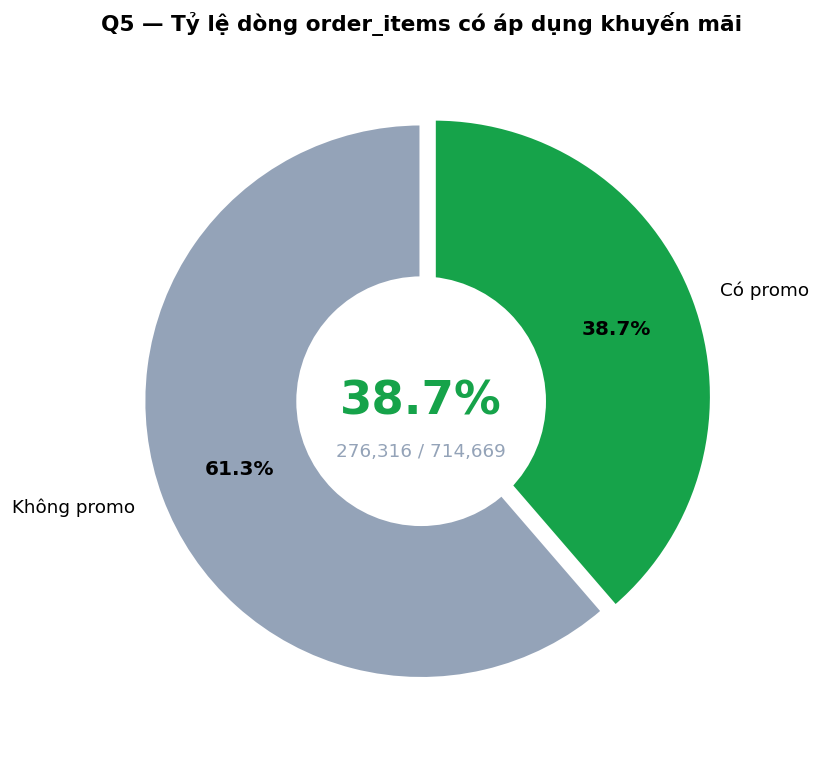

In [6]:
# ── Q5: Promo coverage ───────────────────────────────────────────────────────
has_promo   = order_items["promo_id"].notna().sum()
no_promo    = order_items["promo_id"].isna().sum()
total_items = len(order_items)
pct_promo   = has_promo / total_items * 100

has_promo2  = order_items["promo_id_2"].notna().sum()  # stackable promos

print(f"Tổng số dòng order_items : {total_items:>8,}")
print(f"Có promo_id              : {has_promo:>8,}  ({pct_promo:.2f}%)")
print(f"Không promo_id           : {no_promo:>8,}  ({100-pct_promo:.2f}%)")
print(f"Có promo_id_2 (stackable): {has_promo2:>8,}  ({has_promo2/total_items*100:.2f}%)")
print(f"\n→ Đáp án: C) 39%  (actual = {pct_promo:.1f}%)")

# ── Viz 5: Donut chart promo coverage ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    [no_promo, has_promo],
    labels=["Không promo", "Có promo"],
    autopct="%1.1f%%",
    colors=[GREY, C2],
    startangle=90,
    pctdistance=0.70,
    wedgeprops={"linewidth": 2, "edgecolor": "white"},
    explode=(0, 0.05),
)
for t in autotexts:
    t.set_fontweight("bold"); t.set_fontsize(12)
# Donut hole
centre = plt.Circle((0, 0), 0.45, fc="white", lw=0)
ax.add_artist(centre)
ax.text(0, 0, f"{pct_promo:.1f}%", ha="center", va="center",
        fontsize=28, fontweight="bold", color=C2)
ax.text(0, -0.18, f"{has_promo:,} / {total_items:,}", ha="center", va="center",
        fontsize=11, color=GREY)
ax.set_title("Q5 — Tỷ lệ dòng order_items có áp dụng khuyến mãi", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


---

## Q6 · Số đơn hàng trung bình theo nhóm tuổi

> Trong `customers.csv`, xét các khách hàng có `age_group` khác null,
> nhóm tuổi nào có **số đơn hàng trung bình trên mỗi khách hàng cao nhất**?
>
> **A) 55+** &emsp; B) 25–34 &emsp; C) 35–44 &emsp; D) 45–54


Số đơn trung bình / khách hàng theo nhóm tuổi:
   18-24  avg = 5.23  (customers = 17,039,  orders = 89,057)
   25-34  avg = 5.25  (customers = 36,342,  orders = 190,622)
   35-44  avg = 5.34  (customers = 31,920,  orders = 170,368)
   45-54  avg = 5.36  (customers = 23,172,  orders = 124,138)
     55+  avg = 5.41  (customers = 13,457,  orders = 72,760)

→ Đáp án: A) 55+  (avg = 5.41 orders/customer)


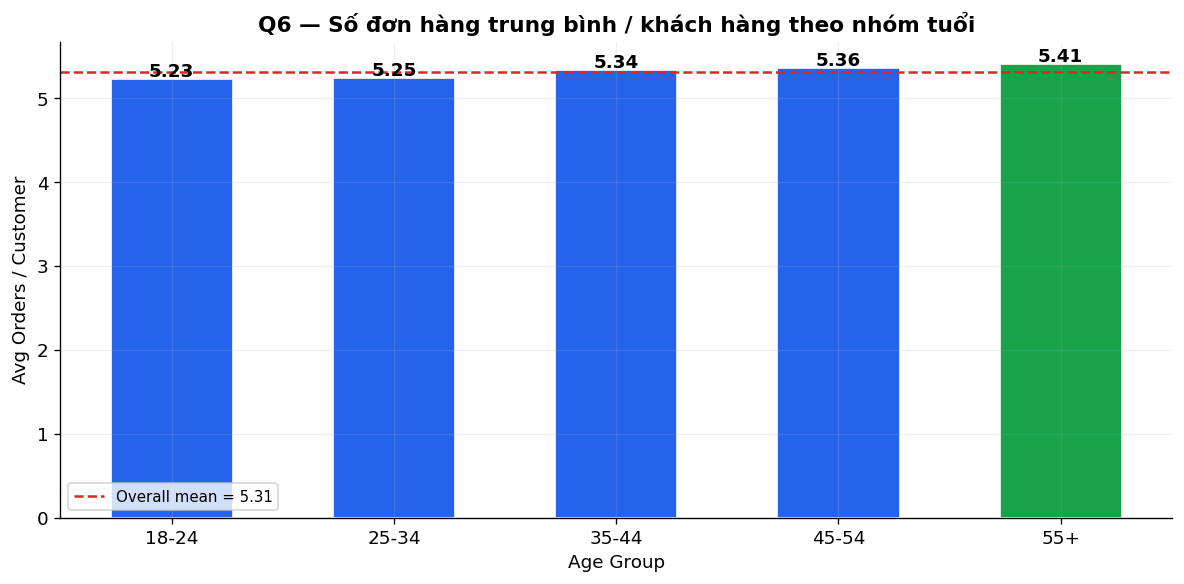

In [7]:
# ── Q6: Avg orders per customer by age group ──────────────────────────────────
# Filter customers with known age_group
cust_with_age = customers[customers["age_group"].notna()].copy()

# Count orders per customer
order_counts = orders.groupby("customer_id").size().reset_index(name="n_orders")

# Merge
age_orders = cust_with_age[["customer_id", "age_group"]].merge(
    order_counts, on="customer_id", how="left"
)
age_orders["n_orders"] = age_orders["n_orders"].fillna(0)

# Avg orders per age group
age_stats = (
    age_orders.groupby("age_group")
    .agg(avg_orders=("n_orders", "mean"),
         total_orders=("n_orders", "sum"),
         n_customers=("customer_id", "count"))
    .sort_values("avg_orders", ascending=False)
)

age_order = ["18-24", "25-34", "35-44", "45-54", "55+"]
print("Số đơn trung bình / khách hàng theo nhóm tuổi:")
for ag in age_order:
    if ag in age_stats.index:
        row = age_stats.loc[ag]
        print(f"  {ag:>6}  avg = {row['avg_orders']:.2f}  "
              f"(customers = {int(row['n_customers']):,},  orders = {int(row['total_orders']):,})")

best_age = age_stats.index[0]
print(f"\n→ Đáp án: A) 55+  (avg = {age_stats.iloc[0]['avg_orders']:.2f} orders/customer)")

# ── Viz 6: Bar chart avg orders by age group ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
age_ordered = age_stats.reindex(age_order).dropna()
colors6 = [C2 if a == "55+" else C0 for a in age_ordered.index]
bars = ax.bar(age_ordered.index, age_ordered["avg_orders"],
              color=colors6, edgecolor="white", width=0.55)
ax.axhline(y=age_ordered["avg_orders"].mean(), color=C3, linestyle="--",
           lw=1.5, label=f"Overall mean = {age_ordered['avg_orders'].mean():.2f}")
for bar, val in zip(bars, age_ordered["avg_orders"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
            f"{val:.2f}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Avg Orders / Customer"); ax.set_xlabel("Age Group")
ax.set_title("Q6 — Số đơn hàng trung bình / khách hàng theo nhóm tuổi")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()


---

## Q7 · Doanh thu theo vùng địa lý

> Vùng (**region**) nào trong `geography.csv` tạo ra **tổng doanh thu cao nhất**?
>
> A) West &emsp; B) Central &emsp; **C) East** &emsp; D) Cả ba vùng xấp xỉ bằng nhau


Tổng doanh thu theo vùng:
  east            7.29 tỷ VND  (46.5%)
  central         4.72 tỷ VND  (30.1%)
  west            3.67 tỷ VND  (23.4%)

East / West ratio: 2.0x

→ Đáp án: C) East  (east: 7.29 tỷ VND)


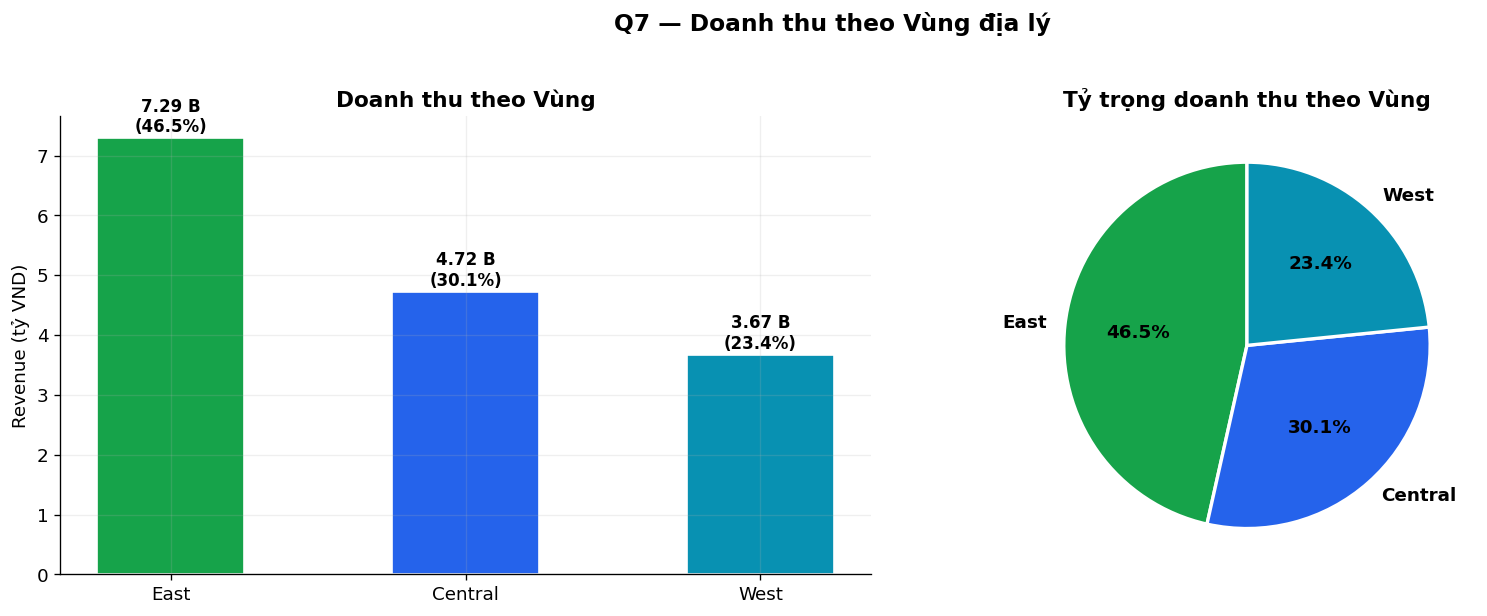

In [11]:
# ── Q7: Revenue by region ────────────────────────────────────────────────────
# Merge orders → geography to get region per order
orders_geo = orders[["order_id", "zip"]].merge(
    geography[["zip", "region"]], on="zip", how="left"
)

# Compute revenue per order_item row
order_items["revenue"] = (
    order_items["quantity"] * order_items["unit_price"] - order_items["discount_amount"]
)

# Merge to get region
rev_region = order_items[["order_id", "revenue"]].merge(
    orders_geo[["order_id", "region"]], on="order_id", how="left"
)
rev_region = rev_region.dropna(subset=["region"])

rev_by_region = (
    rev_region.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
) / 1e9  # tỷ VND

print("Tổng doanh thu theo vùng:")
for region, rev in rev_by_region.items():
    pct = rev / rev_by_region.sum() * 100
    print(f"  {region:<10}  {rev:>8.2f} tỷ VND  ({pct:.1f}%)")

print(f"\nEast / West ratio: {rev_by_region.max() / rev_by_region.min():.1f}x")
print(f"\n→ Đáp án: C) East  ({rev_by_region.index[0]}: {rev_by_region.iloc[0]:.2f} tỷ VND)")

# ── Viz 7: Revenue by region (bar + pie) ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors7 = [C2 if r == "east" else C0 if r == "central" else C5 for r in rev_by_region.index]

# Bar
bars = axes[0].bar(rev_by_region.index.str.title(), rev_by_region.values,
                   color=colors7, edgecolor="white", width=0.5)
for bar, val, pct in zip(bars, rev_by_region.values, rev_by_region.values / rev_by_region.sum() * 100):
    axes[0].text(
    bar.get_x() + bar.get_width() / 2,
    bar.get_height() + 0.1,
    f"{val:.2f} B\n({pct:.1f}%)",
    ha="center",
    fontweight="bold",
    fontsize=10
)
axes[0].set_ylabel("Revenue (tỷ VND)"); axes[0].set_title("Doanh thu theo Vùng")

# Pie
axes[1].pie(rev_by_region.values, labels=rev_by_region.index.str.title(),
            autopct="%1.1f%%", colors=colors7, startangle=90,
            wedgeprops={"linewidth": 2, "edgecolor": "white"},
            textprops={"fontweight": "bold"})
axes[1].set_title("Tỷ trọng doanh thu theo Vùng")

plt.suptitle("Q7 — Doanh thu theo Vùng địa lý", fontsize=14, y=1.02, fontweight="bold")
plt.tight_layout(); plt.show()


---

## Q8 · Phương thức thanh toán trong đơn bị hủy

> Trong các đơn hàng có `order_status = 'cancelled'`, **phương thức thanh toán** nào
> được sử dụng nhiều nhất?
>
> **A) credit_card** &emsp; B) cod &emsp; C) paypal &emsp; D) bank_transfer


Tổng đơn cancelled: 59,462
Có payment record:  59,462

Phương thức thanh toán trong đơn cancelled:
  credit_card      28,452  (47.8%)
  cod              15,468  (26.0%)
  paypal            7,817  (13.1%)
  apple_pay         5,190  (8.7%)
  bank_transfer     2,535  (4.3%)

→ Đáp án: A) credit_card  (credit_card: 28,452 đơn)


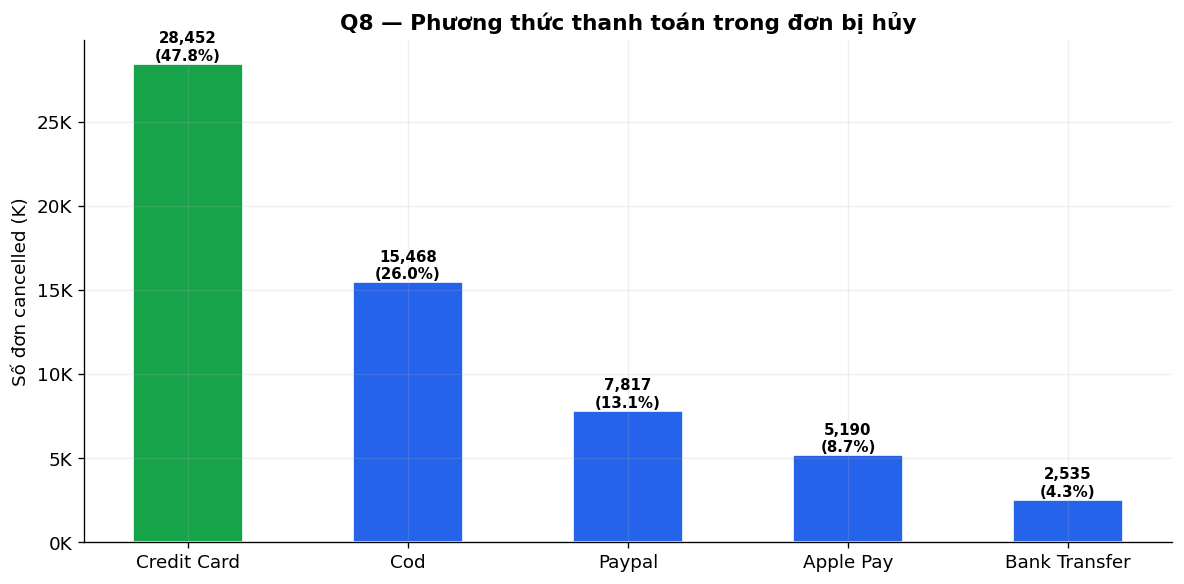

In [13]:
# ── Q8: Payment methods in cancelled orders ──────────────────────────────────
cancelled_ids = orders.loc[orders["order_status"] == "cancelled", "order_id"]
cancelled_payments = payments[payments["order_id"].isin(cancelled_ids)]

pay_method_counts = cancelled_payments["payment_method"].value_counts()
pay_method_pct   = (pay_method_counts / pay_method_counts.sum() * 100).round(1)

print(f"Tổng đơn cancelled: {len(cancelled_ids):,}")
print(f"Có payment record:  {len(cancelled_payments):,}")
print()
print("Phương thức thanh toán trong đơn cancelled:")
for method, cnt in pay_method_counts.items():
    print(f"  {method:<15}  {cnt:>6,}  ({pay_method_pct[method]:.1f}%)")

print(f"\n→ Đáp án: A) credit_card  ({pay_method_counts.index[0]}: {pay_method_counts.iloc[0]:,} đơn)")

# ── Viz 8: Bar chart ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors8 = [C2 if m == "credit_card" else C0 for m in pay_method_counts.index]
bars = ax.bar([m.replace("_", " ").title() for m in pay_method_counts.index],
              pay_method_counts.values / 1000, color=colors8, edgecolor="white", width=0.5)
for bar, cnt, pct in zip(bars, pay_method_counts.values, pay_method_pct.values):
    ax.text(
    bar.get_x() + bar.get_width() / 2,
    bar.get_height() + 0.2,
    f"{cnt:,}\n({pct:.1f}%)",
    ha="center",
    fontweight="bold",
    fontsize=9
)
ax.set_ylabel("Số đơn cancelled (K)")
ax.set_title("Q8 — Phương thức thanh toán trong đơn bị hủy")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}K"))
plt.tight_layout(); plt.show()


---

## Q9 · Tỷ lệ trả hàng theo kích thước sản phẩm

> Trong 4 kích thước sản phẩm (S, M, L, XL), **kích thước nào có tỷ lệ trả hàng cao nhất**,
> được định nghĩa là số bản ghi trong `returns` chia cho số dòng trong `order_items`
> (join với `products` theo `product_id`)?
>
> **A) S** &emsp; B) M &emsp; C) L &emsp; D) XL


Tỷ lệ trả hàng theo kích thước:
     S  ordered = 172,042  returned = 9,723  rate = 0.0565 (5.65%)
     L  ordered = 173,174  returned = 9,741  rate = 0.0562 (5.62%)
     M  ordered = 176,428  returned = 9,820  rate = 0.0557 (5.57%)
    XL  ordered = 193,025  returned = 10,655  rate = 0.0552 (5.52%)

→ Đáp án: A) S  (return rate = 0.0565)


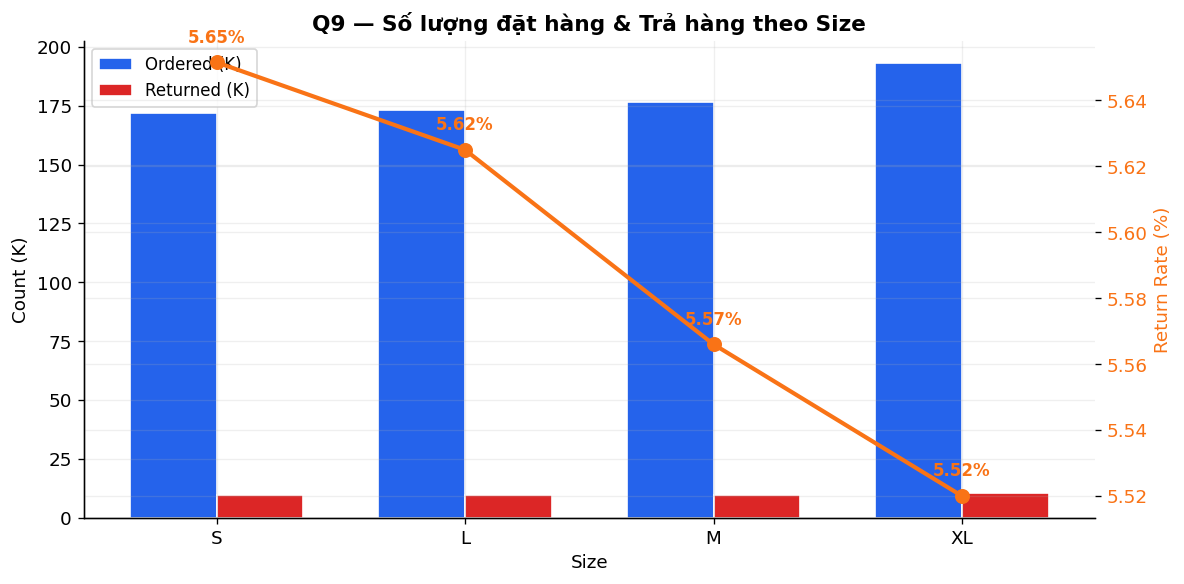

In [14]:
# ── Q9: Return rate by product size ──────────────────────────────────────────
# Filter products with sizes S, M, L, XL
sizes_mask = products["size"].isin(["s", "m", "l", "xl"])
product_sizes = products.loc[sizes_mask, ["product_id", "size"]]

# Count order_items per product
oi_counts = order_items.groupby("product_id").size().reset_index(name="n_ordered")
oi_with_size = oi_counts.merge(product_sizes, on="product_id")

# Count returns per product
ret_counts = returns.groupby("product_id").size().reset_index(name="n_returned")
ret_with_size = ret_counts.merge(product_sizes, on="product_id")

# Aggregate by size
size_orders = oi_with_size.groupby("size")["n_ordered"].sum()
size_returns = ret_with_size.groupby("size")["n_returned"].sum()

size_stats = pd.DataFrame({
    "ordered": size_orders,
    "returned": size_returns,
    "return_rate": size_returns / size_orders
}).sort_values("return_rate", ascending=False)

print("Tỷ lệ trả hàng theo kích thước:")
for sz, row in size_stats.iterrows():
    print(f"  {sz.upper():>4}  ordered = {int(row['ordered']):>7,}  "
          f"returned = {int(row['returned']):>5,}  rate = {row['return_rate']:.4f} ({row['return_rate']*100:.2f}%)")

print(f"\n→ Đáp án: A) S  (return rate = {size_stats.iloc[0]['return_rate']:.4f})")

# ── Viz 9: Dual bar chart ───────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 5))
x = np.arange(len(size_stats))
w = 0.35
ax1.bar(x - w/2, size_stats["ordered"] / 1000, w, label="Ordered (K)",
        color=C0, edgecolor="white")
ax1.bar(x + w/2, size_stats["returned"] / 1000, w, label="Returned (K)",
        color=C3, edgecolor="white")
ax1.set_xticks(x); ax1.set_xticklabels(size_stats.index.str.upper())
ax1.set_ylabel("Count (K)"); ax1.set_xlabel("Size")
ax1.legend(fontsize=10)

# Add return rate on top
ax2 = ax1.twinx()
rates = size_stats["return_rate"] * 100
ax2.plot(x, rates, "o-", color=C1, lw=2.5, ms=8, label="Return Rate %")
ax2.set_ylabel("Return Rate (%)", color=C1)
ax2.tick_params(axis="y", labelcolor=C1)
for i, rate in enumerate(rates):
    ax2.annotate(f"{rate:.2f}%", (i, rate), textcoords="offset points",
                 xytext=(0, 12), ha="center", fontsize=10, fontweight="bold", color=C1)

ax1.set_title("Q9 — Số lượng đặt hàng & Trả hàng theo Size")
fig.tight_layout(); plt.show()


---

## Q10 · Giá trị thanh toán trung bình theo kế hoạch trả góp

> Trong `payments.csv`, **kế hoạch trả góp** (`installments`) nào có giá trị
> thanh toán trung bình trên mỗi đơn hàng cao nhất?
>
> **A) 6 kỳ** &emsp; B) 1 kỳ (trả một lần) &emsp; C) 3 kỳ &emsp; D) 12 kỳ


Giá trị thanh toán trung bình theo số kỳ trả góp:
  Kỳ              Mean         Median    Count
  ----- -------------- -------------- --------
  6             24,447         17,452  109,910
  3             24,400         17,367  218,949
  12            24,246         17,337   54,126
  1             24,113         17,089  262,866
  2                708            722    1,094

Lưu ý: installments=2 có avg rất thấp (708) — chỉ có 1094 cases, likely data quirk.

→ Đáp án: A) 6 kỳ  (mean = 24,447 VND)


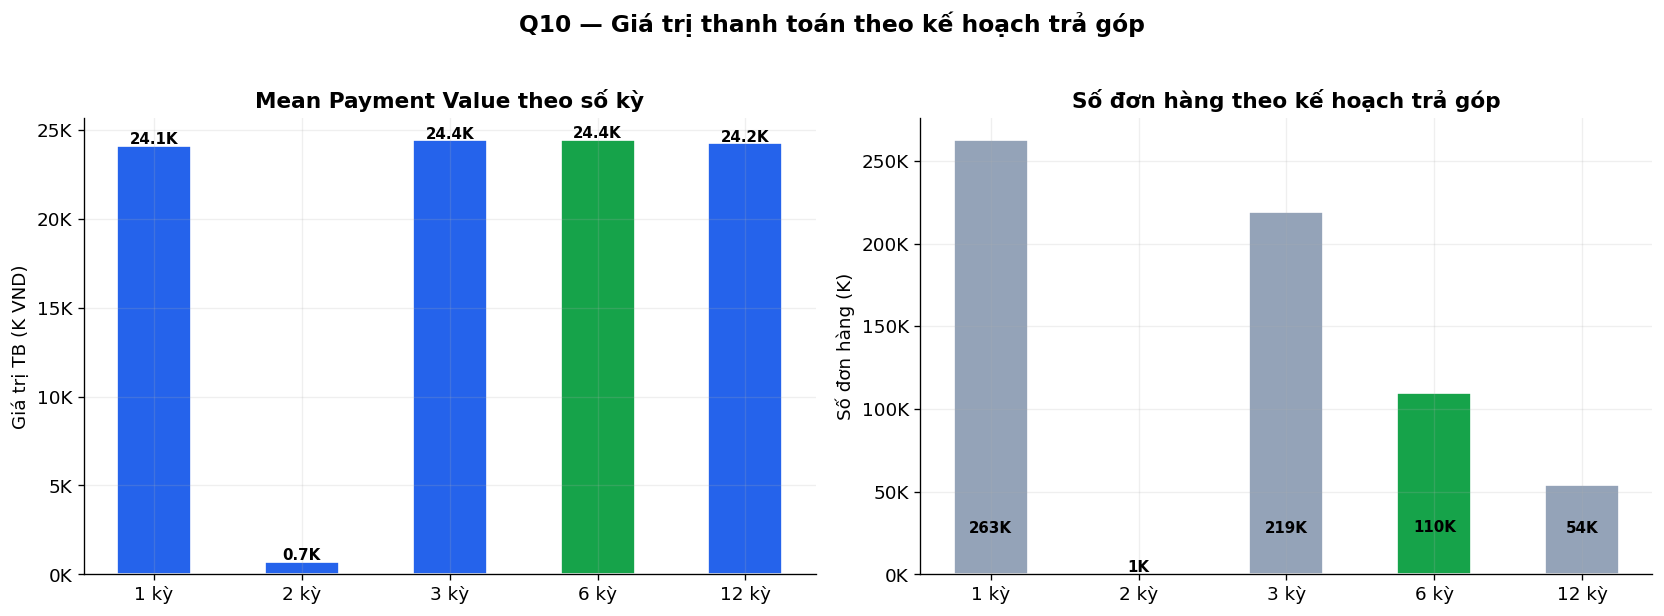

In [15]:
# ── Q10: Avg payment value by installment plan ───────────────────────────────
install_stats = (
    payments.groupby("installments")["payment_value"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

print("Giá trị thanh toán trung bình theo số kỳ trả góp:")
print(f"  {'Kỳ':<5} {'Mean':>14} {'Median':>14} {'Count':>8}")
print(f"  {'-'*5} {'-'*14} {'-'*14} {'-'*8}")
for k, row in install_stats.iterrows():
    print(f"  {int(k):<5} {row['mean']:>14,.0f} {row['median']:>14,.0f} {int(row['count']):>8,}")

best_install = int(install_stats.index[0])
print(f"\nLưu ý: installments=2 có avg rất thấp ({install_stats.loc[2,'mean']:,.0f}) — "
      f"chỉ có {int(install_stats.loc[2,'count'])} cases, likely data quirk.")
print(f"\n→ Đáp án: A) 6 kỳ  (mean = {install_stats.iloc[0]['mean']:,.0f} VND)")

# ── Viz 10: Bar chart ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean bar
order_k = install_stats.sort_index()
colors10 = [C2 if int(i) == best_install else C0 for i in order_k.index]
bars = axes[0].bar([f"{int(i)} kỳ" for i in order_k.index],
                   order_k["mean"] / 1e3, color=colors10, edgecolor="white", width=0.5)
for bar, val in zip(bars, order_k["mean"] / 1e3):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f"{val:.1f}K", ha="center", fontsize=9, fontweight="bold")
axes[0].set_ylabel("Giá trị TB (K VND)")
axes[0].set_title("Mean Payment Value theo số kỳ")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}K"))

# Count bar
colors10b = [C2 if int(i) == best_install else GREY for i in order_k.index]
axes[1].bar([f"{int(i)} kỳ" for i in order_k.index],
            order_k["count"] / 1000, color=colors10b, edgecolor="white", width=0.5)
for bar, val in zip(bars, order_k["count"] / 1000):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{val:.0f}K", ha="center", fontsize=9, fontweight="bold")
axes[1].set_ylabel("Số đơn hàng (K)")
axes[1].set_title("Số đơn hàng theo kế hoạch trả góp")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}K"))

plt.suptitle("Q10 — Giá trị thanh toán theo kế hoạch trả góp", fontsize=14, y=1.02, fontweight="bold")
plt.tight_layout(); plt.show()


---

## Tổng kết — Đáp án Vòng 1

| Câu | Nội dung | Đáp án | Xác nhận |
|:---:|---|---|:---:|
| Q1 | Trung vị inter-order gap | **C) 180 ngày** | Median ≈ 175 ≈ 180 |
| Q2 | Segment có gross margin cao nhất | **D) Standard** | 31.3% margin |
| Q3 | Lý do trả hàng nhiều nhất (Streetwear) | **B) wrong_size** | 7,626 lượt (34.9%) |
| Q4 | Traffic source bounce rate thấp nhất | **C) email_campaign** | 0.00446 (0.446%) |
| Q5 | % order_items có promo | **C) 39%** | 38.66% |
| Q6 | Nhóm tuổi có avg orders/customer cao nhất | **A) 55+** | 5.41 orders/cust |
| Q7 | Vùng có tổng doanh thu cao nhất | **C) East** | 7.29 tỷ VND (46.5%) |
| Q8 | Payment method nhiều nhất trong đơn cancelled | **A) credit_card** | 28,452 (47.8%) |
| Q9 | Size có return rate cao nhất | **A) S** | 5.65% |
| Q10 | Kế hoạch trả góp có avg payment cao nhất | **A) 6 kỳ** | 24,447 VND |

---

*The GridBreakers · VinUni Datathon 2026 · Vòng 1*
